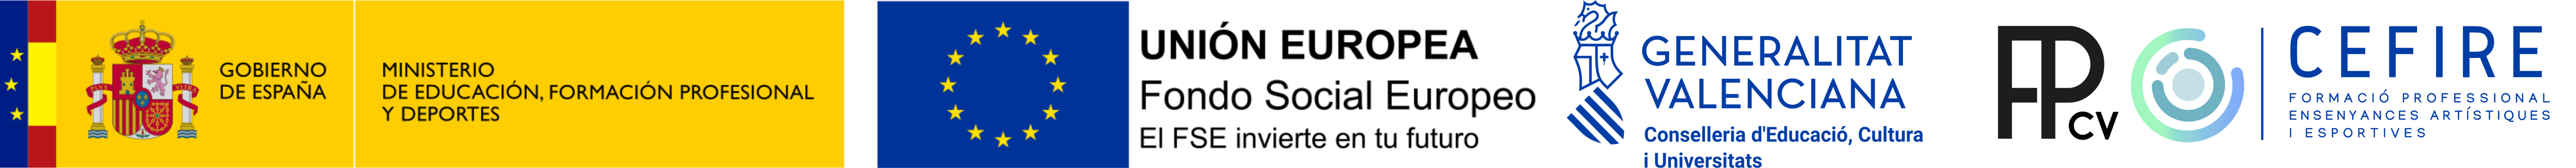

## Regresión: Preparación de los datos: ##

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline

In [2]:
# EJECUTAR ESTA CELDA SI ESTAMOS EN JUPYTER NOTEBOOK O VSCODE EN LOCAL:
df = pd.read_csv("FuelConsumption.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [ ]:
# EJECUTAR ESTA CELDA SI ESTAMOS EN GOOGLE COLAB:
# Debemos haber dejado el dataset en la carpeta 'Colab Notebooks" del DRIVE.
# Conectaremos el drive y cargaremos el dataset de la carpeta de colab Notebooks.
# Avisamos del error si no encontramos el dataset

from google.colab import drive
import pandas as pd

try:
  drive.mount('/content/drive')
  # Ruta al archivo CSV en tu Google Drive
  file_path = '/content/drive/MyDrive/Colab Notebooks/FuelConsumption.csv'  # Reemplaza con la ruta correcta
  df = pd.read_csv(file_path)
except FileNotFoundError:
  print(f"Error: El archivo CSV no se encontró en la ruta especificada: {file_path}")
except Exception as e:
  print(f"Error al cargar el archivo CSV: {e}")


In [ ]:
# EJECUTAR ESTA CELDA SI ESTAMOS EN GOOGLE COLAB:
df.head()

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   str    
 2   MODEL                     1067 non-null   str    
 3   VEHICLECLASS              1067 non-null   str    
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   str    
 7   FUELTYPE                  1067 non-null   str    
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), str(5)
memory usage: 108.5 KB


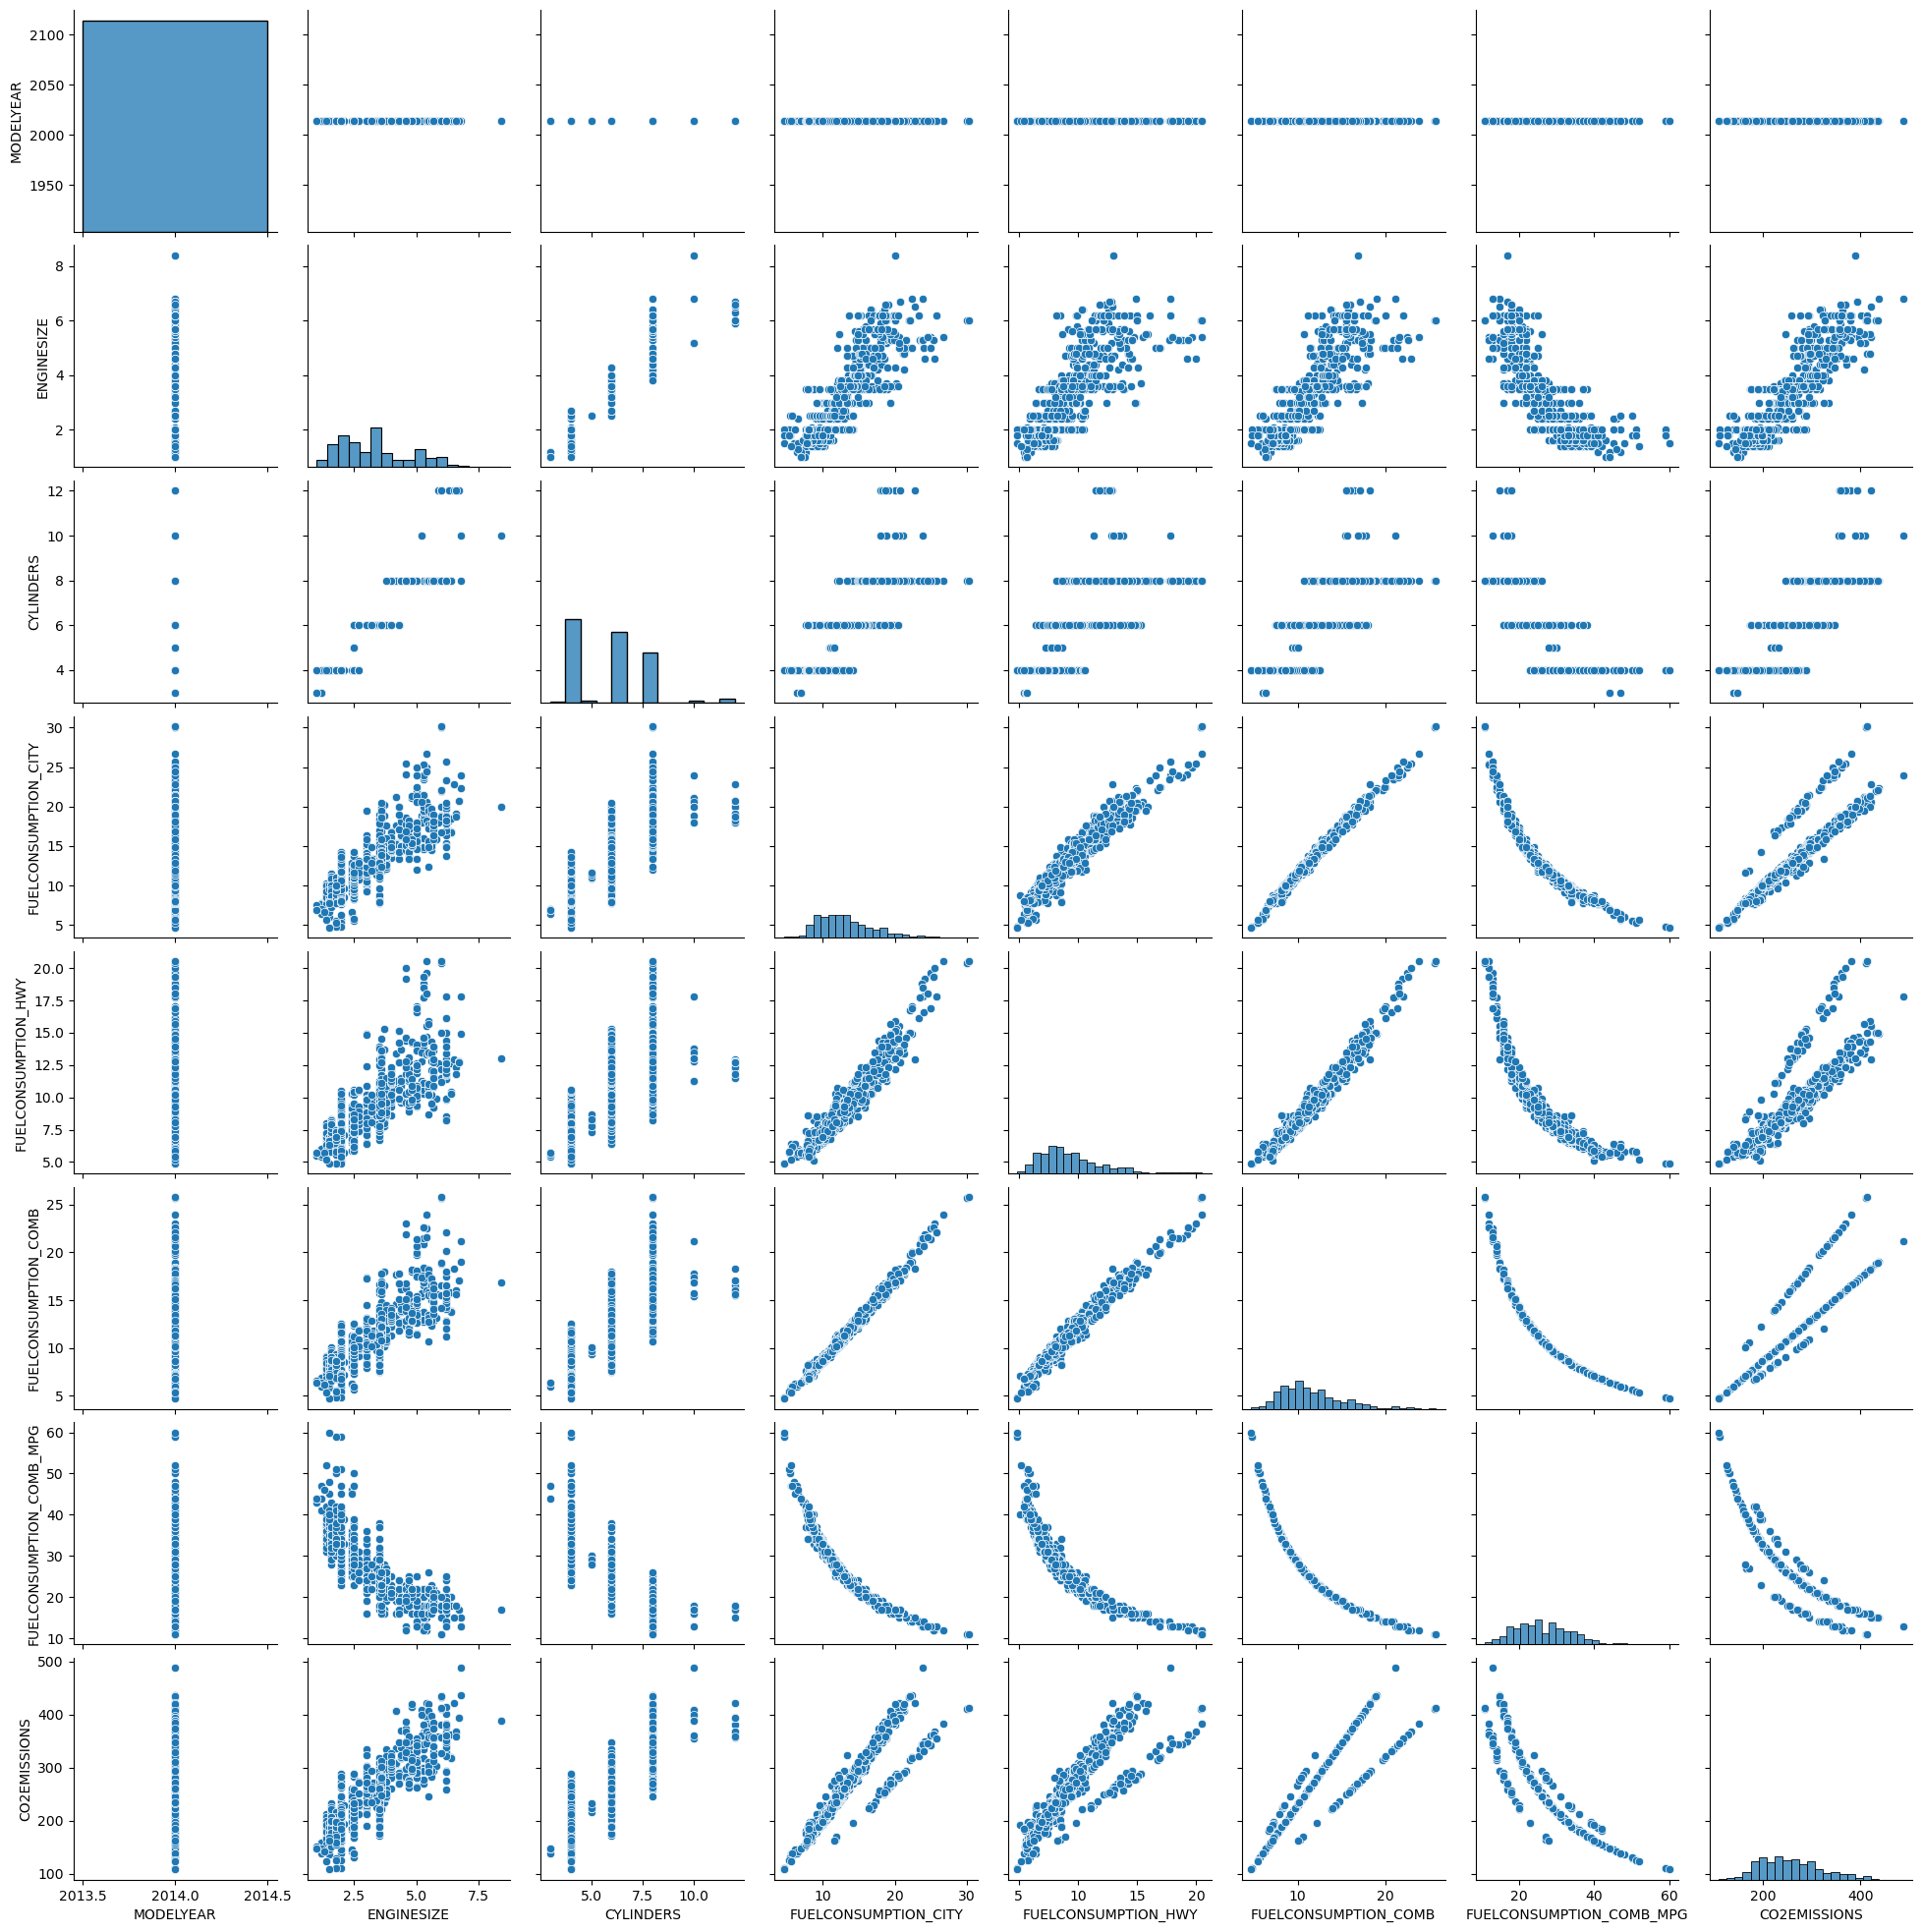

In [4]:
# Seleccionar solo las columnas numéricas
cdf = df[['MODELYEAR', 'ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY',
          'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB',
          'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS']]
# Crear la matriz de gráficos de dispersión
sns.pairplot(cdf)

# Mostrar los gráficos
plt.show()

In [5]:
# Seleccionar columnas de interés
cdf = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]

In [6]:
from sklearn.model_selection import train_test_split

# --- División en Entrenamiento y Prueba ---
# Para la mayoría de los ejemplos, usaremos múltiples características
X_multi = cdf[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']] #Características o variables independientes
y = cdf['CO2EMISSIONS'] #Target o variable objetivo/dependiente
# Como norma general el 80% es para entrenamiento (X_train_multi,y_train) y el 20% para test(X_test_multi,y_test)
X_train_multi, X_test_multi, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# Para regresión lineal simple y polinómica (con una variable para visualizar)
X_simple = cdf[['ENGINESIZE']] # Usaremos ENGINESIZE como única característica
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y, test_size=0.2, random_state=42)
# Nota: y_train e y_test son los mismos en ambos casos si usamos la misma random_state

print(f"Tamaño del conjunto de entrenamiento (múltiple): {X_train_multi.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba (múltiple): {X_test_multi.shape[0]} muestras")
print(f"Tamaño del conjunto de entrenamiento (simple): {X_train_simple.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba (simple): {X_test_simple.shape[0]} muestras")


Tamaño del conjunto de entrenamiento (múltiple): 853 muestras
Tamaño del conjunto de prueba (múltiple): 214 muestras
Tamaño del conjunto de entrenamiento (simple): 853 muestras
Tamaño del conjunto de prueba (simple): 214 muestras


## Regresión Lineal Simple: ##


--- Evaluación del Modelo (sobre datos de prueba) ---

--- Evaluación (Simple) ---
MSE: 985.94
RMSE: 31.40
R²: 0.7616


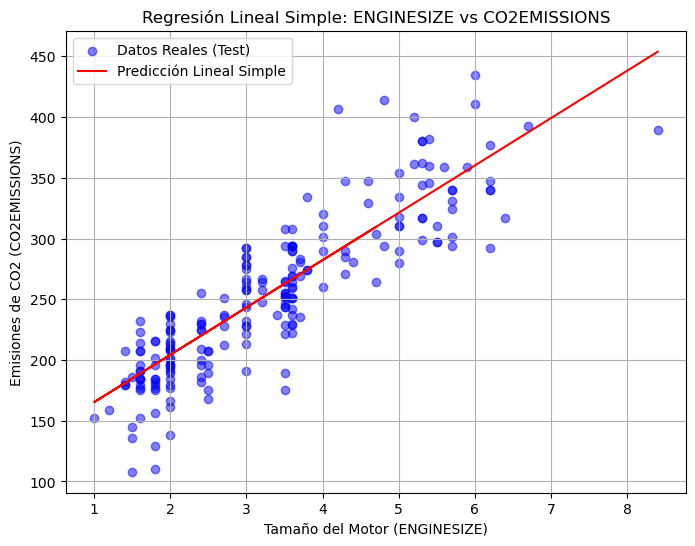

In [7]:
#CODIGO BÁSICO SIN LA MAYORIA DE COMENTARIOS EXPLICATIVOS:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
# 1. Crear instancia del modelo
lin_reg_simple = LinearRegression()

# 2. Entrenar el modelo (usando solo ENGINESIZE)
lin_reg_simple.fit(X_train_simple, y_train_simple)

# 3. Coeficientes encontrados e interpretación
beta_1 = lin_reg_simple.coef_[0]
beta_0 = lin_reg_simple.intercept_

# 4. Predecir en el conjunto de prueba
y_pred_simple = lin_reg_simple.predict(X_test_simple)

# 5. Evaluar e interpretar métricas: R1, MSE, RMSE
print(f"\n--- Evaluación del Modelo (sobre datos de prueba) ---")
r2_simple = r2_score(y_test_simple, y_pred_simple)
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
print(f"\n--- Evaluación (Simple) ---")
print(f"MSE: {mse_simple:.2f}")
print(f"RMSE: {rmse_simple:.2f}")
print(f"R²: {r2_simple:.4f}")

# 6. Visualización (Opcional pero Recomendado)
plt.figure(figsize=(8, 6))
plt.scatter(X_test_simple, y_test_simple, color='blue', alpha=0.5, label='Datos Reales (Test)')
# X_test_simple es un Dataframe y la función plot espera un array de 1 dimensión 
# por lo que extraemos la columna como una Serie con .iloc[:, 0]
plt.plot(X_test_simple.iloc[:, 0], y_pred_simple, color='red', label='Predicción Lineal Simple')

plt.title('Regresión Lineal Simple: ENGINESIZE vs CO2EMISSIONS')
plt.xlabel('Tamaño del Motor (ENGINESIZE)')
plt.ylabel('Emisiones de CO2 (CO2EMISSIONS)')
plt.legend()
plt.grid(True)
plt.show()

--- Coeficientes del Modelo Lineal Simple ---
Coeficiente (Pendiente β₁ - ENGINESIZE): 38.99
  Interpretación β₁: Por cada unidad de aumento en ENGINESIZE, las CO2EMISSIONS aumentan en promedio 38.99 g/km.
Intersección (β₀): 126.29
  Interpretación β₀: El valor base predicho para CO2EMISSIONS cuando ENGINESIZE es 0 es 126.29 g/km (puede no tener sentido físico directo).
  Ecuación del modelo Regresión Lineal Simple: CO2EMISSIONS ≈ 126.29 + 38.99 * ENGINESIZE

--- Evaluación del Modelo (sobre datos de prueba) ---
R² (Coeficiente de Determinación): 0.7616
  Interpretación R²: Aproximadamente el 76.16% de la varianza en las emisiones de CO2 (en el test set) es explicada por el tamaño del motor según este modelo lineal.

MSE (Mean Squared Error): 985.94
  Interpretación MSE: Es el promedio de los errores al cuadrado. Útil para comparar modelos, pero sus unidades ( (g/km)^2 ) son menos intuitivas.

RMSE (Root Mean Squared Error): 31.40
  Interpretación RMSE: En promedio, las predicciones de

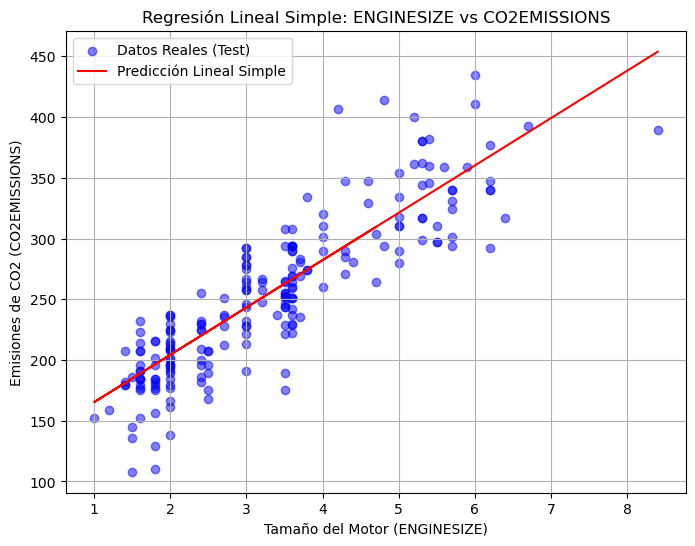

In [8]:
#CODIGO CON COMENTARIOS EXPLICATIVOS:
# Código - Regresión Lineal Simple
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# 1. Crear instancia del modelo
lin_reg_simple = LinearRegression()

# 2. Entrenar el modelo (usando solo ENGINESIZE)
# Asegurarse que X_train_simple sea 2D: Scikit-learn espera [n_samples, n_features]
lin_reg_simple.fit(X_train_simple, y_train_simple) # y_train_simple es igual a y_train

# 3. Coeficientes encontrados e interpretación
beta_1 = lin_reg_simple.coef_[0]
beta_0 = lin_reg_simple.intercept_
print(f"--- Coeficientes del Modelo Lineal Simple ---")
print(f"Coeficiente (Pendiente β₁ - ENGINESIZE): {beta_1:.2f}")
print(f"  Interpretación β₁: Por cada unidad de aumento en ENGINESIZE, las CO2EMISSIONS aumentan en promedio {beta_1:.2f} g/km.")
print(f"Intersección (β₀): {beta_0:.2f}")
print(f"  Interpretación β₀: El valor base predicho para CO2EMISSIONS cuando ENGINESIZE es 0 es {beta_0:.2f} g/km (puede no tener sentido físico directo).")
print(f"  Ecuación del modelo Regresión Lineal Simple: CO2EMISSIONS ≈ {beta_0:.2f} + {beta_1:.2f} * ENGINESIZE")


# 4. Predecir en el conjunto de prueba
y_pred_simple = lin_reg_simple.predict(X_test_simple)

# 5. Evaluar e interpretar métricas: R1, MSE, RMSE
print(f"\n--- Evaluación del Modelo (sobre datos de prueba) ---")

# R²
r2_simple = r2_score(y_test_simple, y_pred_simple)
print(f"R² (Coeficiente de Determinación): {r2_simple:.4f}")
print(f"  Interpretación R²: Aproximadamente el {r2_simple*100:.2f}% de la varianza en las emisiones de CO2 (en el test set) es explicada por el tamaño del motor según este modelo lineal.")

# MSE
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
print(f"\nMSE (Mean Squared Error): {mse_simple:.2f}")
print(f"  Interpretación MSE: Es el promedio de los errores al cuadrado. Útil para comparar modelos, pero sus unidades ( (g/km)^2 ) son menos intuitivas.")

# RMSE
rmse_simple = np.sqrt(mse_simple)
print(f"\nRMSE (Root Mean Squared Error): {rmse_simple:.2f}")
print(f"  Interpretación RMSE: En promedio, las predicciones de emisiones de CO2 del modelo se desvían unos {rmse_simple:.2f} g/km de los valores reales. Es el error típico en las unidades originales.")


print(f"\n--- Evaluación (Simple) ---")
print(f"MSE: {mse_simple:.2f}")
print(f"RMSE: {rmse_simple:.2f}")
print(f"R²: {r2_simple:.4f}")

# 6. Visualización (Opcional pero Recomendado)
plt.figure(figsize=(8, 6))
plt.scatter(X_test_simple, y_test_simple, color='blue', alpha=0.5, label='Datos Reales (Test)')
# X_test_simple es un Dataframe y la función plot espera un array de 1 dimensión 
# por lo que extraemos la columna como una Serie con .iloc[:, 0]
plt.plot(X_test_simple.iloc[:, 0], y_pred_simple, color='red', label='Predicción Lineal Simple')
plt.title('Regresión Lineal Simple: ENGINESIZE vs CO2EMISSIONS')
plt.xlabel('Tamaño del Motor (ENGINESIZE)')
plt.ylabel('Emisiones de CO2 (CO2EMISSIONS)')
plt.legend()
plt.grid(True)
plt.show()

## Regresión Lineal Múltiple: ##

In [9]:
#CODIGO SIN LA MAYORIA DE COMENTARIOS EXPLICATIVOS:
# Regresión Lineal Múltiple
# 1. Crear instancia del modelo
lin_reg_multi = LinearRegression()

# 2. Entrenar el modelo
lin_reg_multi.fit(X_train_multi, y_train)

# 3. Coeficientes encontrados
print("Coeficientes (β₁, β₂, ...):")
for feature, coef in zip(X_train_multi.columns, lin_reg_multi.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"Intersección (β₀): {lin_reg_multi.intercept_:.2f}")

# 4. Predecir en el conjunto de prueba
y_pred_multi = lin_reg_multi.predict(X_test_multi)

# 5. Evaluar e interpretar métricas
print(f"\n--- Evaluación del Modelo Múltiple (sobre datos de prueba) ---")
r2_multi = r2_score(y_test, y_pred_multi)
mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
print(f"\n--- Evaluación (Múltiple) ---")
print(f"MSE: {mse_multi:.2f}")
print(f"RMSE: {rmse_multi:.2f}")
print(f"R²: {r2_multi:.4f}")

print(f"\nComparación R² Simple vs Múltiple: {r2_simple:.4f} vs {r2_multi:.4f}")
# Observamos si el R² mejora al usar más características


Coeficientes (β₁, β₂, ...):
  ENGINESIZE: 11.21
  CYLINDERS: 7.16
  FUELCONSUMPTION_COMB: 9.52
Intersección (β₀): 67.35

--- Evaluación del Modelo Múltiple (sobre datos de prueba) ---

--- Evaluación (Múltiple) ---
MSE: 512.86
RMSE: 22.65
R²: 0.8760

Comparación R² Simple vs Múltiple: 0.7616 vs 0.8760


--- Coeficientes del Modelo Lineal Múltiple ---
Intersección (β₀): 67.35
  Interpretación β₀: Valor predicho de CO2EMISSIONS si ENGINESIZE, CYLINDERS y FUELCONSUMPTION_COMB fueran todos cero (interpretación física limitada).

Coeficientes (β₁, β₂, ...):
  Coeficiente para 'ENGINESIZE' (βᵢ): 11.21
    Interpretación βᵢ: Por cada unidad de aumento en 'ENGINESIZE', se espera que CO2EMISSIONS cambie en 11.21 g/km, *manteniendo constantes las otras variables* (CYLINDERS, FUELCONSUMPTION_COMB).
  Coeficiente para 'CYLINDERS' (βᵢ): 7.16
    Interpretación βᵢ: Por cada unidad de aumento en 'CYLINDERS', se espera que CO2EMISSIONS cambie en 7.16 g/km, *manteniendo constantes las otras variables* (ENGINESIZE, FUELCONSUMPTION_COMB).
  Coeficiente para 'FUELCONSUMPTION_COMB' (βᵢ): 9.52
    Interpretación βᵢ: Por cada unidad de aumento en 'FUELCONSUMPTION_COMB', se espera que CO2EMISSIONS cambie en 9.52 g/km, *manteniendo constantes las otras variables* (ENGINESIZE, CYLINDERS).

Ecuación del modelo:

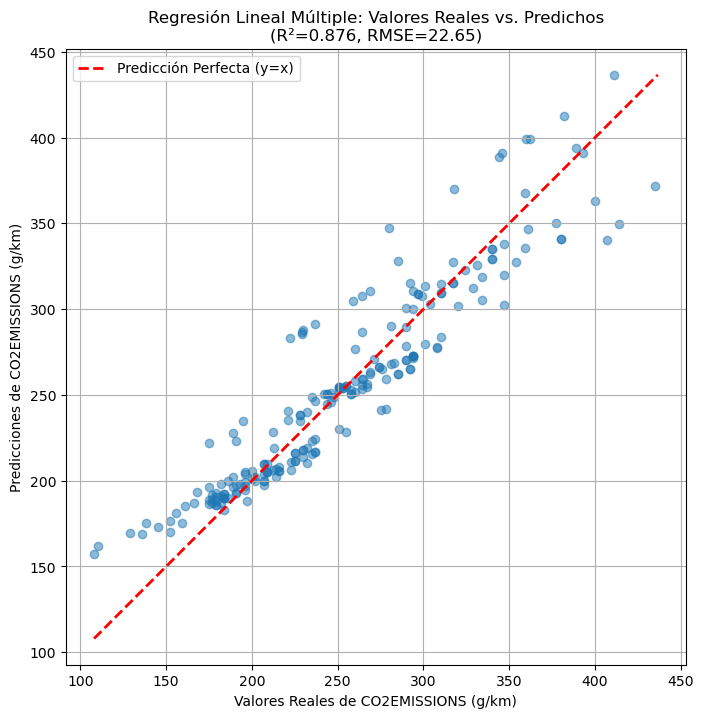

Interpretación del gráfico: Los puntos representan cada predicción de CO2.
Si la predicción hubiera sido perfecta el valor de CO2 predicho coincidiria con el real
y los puntos deberían haber caido sobre la línea roja discontinua (predicción perfecta).
La dispersión de los puntos alrededor de la línea indica el error del modelo.


In [10]:
#CODIGO CON COMENTARIOS EXPLICATIVOS:
# Regresión Lineal Múltiple
# 1. Crear instancia del modelo
lin_reg_multi = LinearRegression()

# 2. Entrenar el modelo
lin_reg_multi.fit(X_train_multi, y_train)

# 3. Coeficientes encontrados e interpretación
print("--- Coeficientes del Modelo Lineal Múltiple ---")

beta_0_multi = lin_reg_multi.intercept_
print(f"Intersección (β₀): {beta_0_multi:.2f}")
print(f"  Interpretación β₀: Valor predicho de CO2EMISSIONS si ENGINESIZE, CYLINDERS y FUELCONSUMPTION_COMB fueran todos cero (interpretación física limitada).")

print("\nCoeficientes (β₁, β₂, ...):")
coef_interpretations = []
feature_names = X_train_multi.columns # Asegúrate que X_train_multi tenga nombres de columnas
for feature, coef in zip(feature_names, lin_reg_multi.coef_):
    print(f"  Coeficiente para '{feature}' (βᵢ): {coef:.2f}")
    print(f"    Interpretación βᵢ: Por cada unidad de aumento en '{feature}', se espera que CO2EMISSIONS cambie en {coef:.2f} g/km, *manteniendo constantes las otras variables* ({', '.join(f for f in feature_names if f != feature)}).")
    coef_interpretations.append(f"({coef:.2f} * {feature})")

# Construir la ecuación del modelo
equation = f"CO2EMISSIONS ≈ {beta_0_multi:.2f} + {' + '.join(coef_interpretations)}"
print(f"\nEcuación del modelo:\n{equation}")

# 4. Predecir en el conjunto de prueba
y_pred_multi = lin_reg_multi.predict(X_test_multi)

# 5. Evaluar e interpretar métricas
print(f"\n--- Evaluación del Modelo Múltiple (sobre datos de prueba) ---")

# R²
r2_multi = r2_score(y_test, y_pred_multi)
print(f"R² (Coeficiente de Determinación): {r2_multi:.4f}")
print(f"  Interpretación R²: Aproximadamente el {r2_multi*100:.2f}% de la varianza en CO2EMISSIONS (test set) es explicada por el conjunto de variables {list(feature_names)} en este modelo lineal.")

# MSE
mse_multi = mean_squared_error(y_test, y_pred_multi)
print(f"\nMSE (Mean Squared Error): {mse_multi:.2f}")
print(f"  Interpretación MSE: Promedio de los errores al cuadrado para el modelo múltiple. Unidades: (g/km)^2.")

# RMSE
rmse_multi = np.sqrt(mse_multi)
print(f"\nRMSE (Root Mean Squared Error): {rmse_multi:.2f}")
print(f"  Interpretación RMSE: En promedio, las predicciones de este modelo múltiple se desvían unos {rmse_multi:.2f} g/km de los valores reales de CO2EMISSIONS.")

# 6. Comparación con Regresión Simple (Asumiendo r2_simple calculado previamente)
# Definir r2_simple si no viene de antes (solo para ejemplo)
# r2_simple = 0.7616 # Valor obtenido antes
try:
    print(f"\n--- Comparación de Ajuste ---")
    print(f"R² (Simple con ENGINESIZE): {r2_simple:.4f}")
    print(f"R² (Múltiple con {list(feature_names)}): {r2_multi:.4f}")
    if r2_multi > r2_simple:
        print("  Conclusión: Añadir las variables adicionales ha mejorado la capacidad explicativa del modelo lineal.")
    else:
        print("  Conclusión: Añadir las variables adicionales NO ha mejorado (o ha empeorado ligeramente) la capacidad explicativa del modelo lineal en el test set.")
except NameError:
    print("\nVariable 'r2_simple' no encontrada para comparación.")

# 7. Visualización (Actual vs. Predicho)
print("\n--- Visualización: Valores Reales vs. Predicciones ---")
print("""No podemos visualizar directamente la relación entre 3+ variables predictoras y la variable
  objetivo en un gráfico 2D simple como hacíamos con la regresión lineal simple (que era una línea),
  una visualización muy útil y estándar para cualquier modelo de regresión (incluido el múltiple) es
  graficar los valores reales contra los valores predichos.
->Idea de la Visualización:
Eje X: Valores reales de CO2EMISSIONS del conjunto de prueba (y_test).
Eje Y: Valores predichos por el modelo múltiple para esas mismas muestras (y_pred_multi).
Línea de Referencia: Una línea diagonal (y=x) que representa la predicción perfecta (donde predicho == real).
Si el modelo es bueno, los puntos (real, predicho) deberían agruparse cerca de esta línea diagonal.
La dispersión alrededor de la línea da una idea visual del error del modelo (relacionado con el RMSE y R²).\n
""");

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_multi, alpha=0.5)

# Añadir la línea de referencia y=x (predicción perfecta)
min_val = min(y_test.min(), y_pred_multi.min())
max_val = max(y_test.max(), y_pred_multi.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (y=x)')

plt.title(f'Regresión Lineal Múltiple: Valores Reales vs. Predichos\n(R²={r2_multi:.3f}, RMSE={rmse_multi:.2f})')
plt.xlabel('Valores Reales de CO2EMISSIONS (g/km)')
plt.ylabel('Predicciones de CO2EMISSIONS (g/km)')
plt.legend()
plt.grid(True)
# Asegurar que los ejes tengan escalas comparables si es posible
plt.axis('equal') # Forza a que la escala en X e Y sea la misma
plt.show()

print("Interpretación del gráfico: Los puntos representan cada predicción de CO2.")
print("Si la predicción hubiera sido perfecta el valor de CO2 predicho coincidiria con el real")
print("y los puntos deberían haber caido sobre la línea roja discontinua (predicción perfecta).")
print("La dispersión de los puntos alrededor de la línea indica el error del modelo.")



## Regresión Polinómica: ##

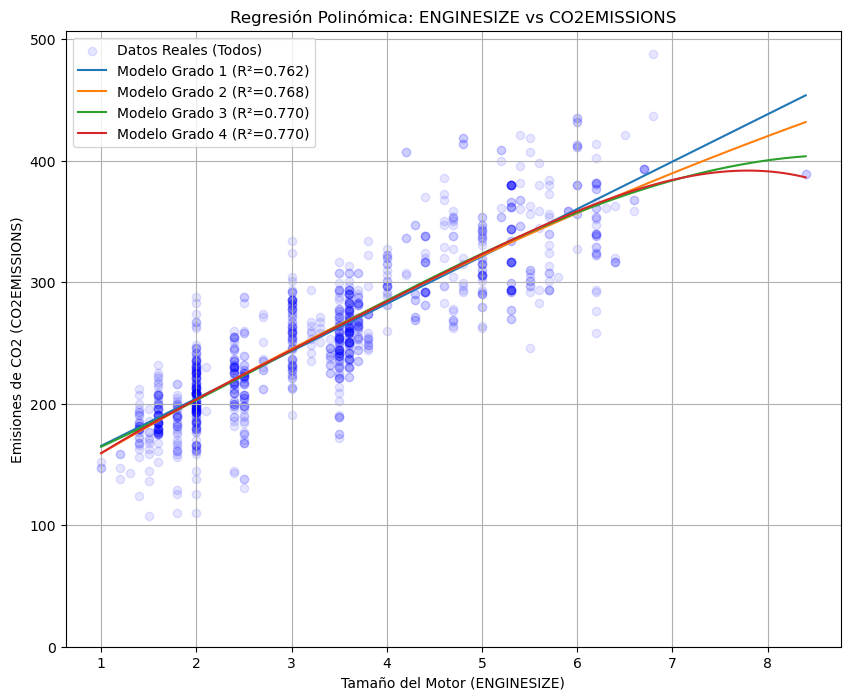


--- Resultados Regresión Polinómica (ordenados por R² en Test) ---
   Grado         MSE       RMSE  R² (Test)
2      3  950.522376  30.830543   0.770125
3      4  952.920251  30.869406   0.769545
1      2  960.870583  30.997913   0.767622
0      1  985.938169  31.399652   0.761560


In [11]:
#CODIGO SIN LA MAYORIA DE COMENTARIOS EXPLICATIVOS:
from sklearn.preprocessing import PolynomialFeatures

# Usaremos X_simple (ENGINESIZE) para poder visualizar fácilmente la curva
# Aunque podríamos aplicar PolynomialFeatures a X_multi también
degrees = [1, 2, 3, 4] # Grados a evaluar
results_poly = [] # Lista para almacenar resultados

plt.figure(figsize=(10, 8))
# Mostrar todos para ver la tendencia
plt.scatter(X_simple, y, color='blue', alpha=0.1, label='Datos Reales (Todos)')

for degree in degrees:
    # 1. Crear el transformador de características polinómicas
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    # include_bias=False porque LinearRegression lo añade
    # 2. Transformar los datos de entrenamiento y prueba
    X_train_poly = poly_features.fit_transform(X_train_simple)
    X_test_poly = poly_features.transform(X_test_simple)
    # print(f"Grado {degree}: {X_train_poly.shape[1]} características generadas.")
    # 3. Crear y entrenar el modelo de regresión lineal sobre datos transformados
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train_simple)
    # 4. Generar predicciones en el conjunto de prueba
    y_pred_poly = poly_model.predict(X_test_poly)
    # 5. Calcular métricas en el conjunto de prueba
    mse = mean_squared_error(y_test_simple, y_pred_poly)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_simple, y_pred_poly)
    # Almacenar los resultados
    results_poly.append((degree, mse, rmse, r2))
    # 6. Graficar la curva del modelo
    # Generar puntos para la línea/curva suave
    X_range = np.linspace(X_simple.min(), X_simple.max(), 100).reshape(-1, 1)
    # Convertir a Dataframe de pandas para evitar warning X_range es un array NumPy sin nombres de columnas
    X_range_poly = poly_features.transform(
    pd.DataFrame(X_range, columns=["ENGINESIZE"])
    )
    y_range_pred = poly_model.predict(X_range_poly)

    plt.plot(X_range, y_range_pred, label=f"Modelo Grado {degree} (R²={r2:.3f})")

# Configuraciones finales del gráfico
plt.title("Regresión Polinómica: ENGINESIZE vs CO2EMISSIONS")
plt.xlabel("Tamaño del Motor (ENGINESIZE)")
plt.ylabel("Emisiones de CO2 (CO2EMISSIONS)")
plt.legend()
plt.grid(True)
plt.ylim(bottom=0) # Emisiones no deben ser negativas
plt.show()

# Crear un DataFrame con los resultados y ordenarlos
results_poly_df = pd.DataFrame(results_poly,
        columns=["Grado", "MSE", "RMSE", "R² (Test)"]).sort_values(by="R² (Test)", ascending=False)
print("\n--- Resultados Regresión Polinómica (ordenados por R² en Test) ---")
print(results_poly_df)

# Discusión: ¿Qué grado parece ofrecer el mejor compromiso entre ajuste y complejidad según R² en Test?
# El grado 1 es la regresión lineal simple que ya hicimos.

--- Evaluación de Diferentes Grados Polinómicos ---

--- Evaluando Grado Polinómico: 1 ---
Métricas para Grado 1 (en Test Set):
  R²: 0.7616
    Interpretación R²: El modelo polinómico de grado 1 explica ~76.16% de la varianza de CO2EMISSIONS en el test set.
  MSE: 985.94
    Interpretación MSE: Error cuadrático medio para grado 1.
  RMSE: 31.40
    Interpretación RMSE: El error típico de predicción para grado 1 es ~31.40 g/km de CO2.

--- Evaluando Grado Polinómico: 2 ---
Métricas para Grado 2 (en Test Set):
  R²: 0.7676
    Interpretación R²: El modelo polinómico de grado 2 explica ~76.76% de la varianza de CO2EMISSIONS en el test set.
  MSE: 960.87
    Interpretación MSE: Error cuadrático medio para grado 2.
  RMSE: 31.00
    Interpretación RMSE: El error típico de predicción para grado 2 es ~31.00 g/km de CO2.

--- Evaluando Grado Polinómico: 3 ---
Métricas para Grado 3 (en Test Set):
  R²: 0.7701
    Interpretación R²: El modelo polinómico de grado 3 explica ~77.01% de la varianza

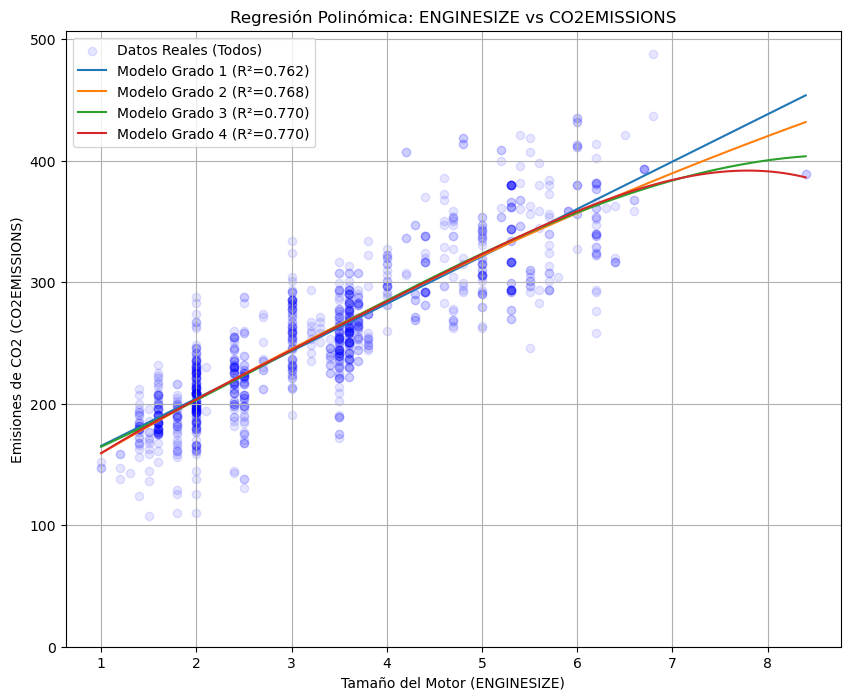


--- Resumen de Resultados Regresión Polinómica (ordenados por R² en Test) ---
 Grado  MSE (Test)  RMSE (Test)  R² (Test)
     3  950.522376    30.830543   0.770125
     4  952.920251    30.869406   0.769545
     2  960.870583    30.997913   0.767622
     1  985.938169    31.399652   0.761560

Nota: Elegir el grado con mejor métrica en 'Test' (ej. mayor R² o menor RMSE),
cuidando no sobreajustar (comparar con métricas en Train si se calcularan).

--- Extrayendo la Función para el Mejor Modelo (Grado 3) ---
La función estimada por el modelo polinómico de grado 3 es:
CO2EMISSIONS ≈ 131.299 + 29.922 * (ENGINESIZE^1) + 3.772 * (ENGINESIZE^2) - 0.414 * (ENGINESIZE^3)


In [12]:
#CODIGO CON COMENTARIOS EXPLICATIVOS:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Asumiendo que X_train_simple, y_train_simple, X_test_simple, y_test_simple ---
# --- y X_simple, y (datos completos) ya existen ---
# (Código de carga y división de datos iría aquí)

degrees = [1, 2, 3, 4] # Grados a evaluar
results_poly = [] # Lista para almacenar resultados

print("--- Evaluación de Diferentes Grados Polinómicos ---")

plt.figure(figsize=(10, 8))
plt.scatter(X_simple, y, color='blue', alpha=0.1, label='Datos Reales (Todos)')

# Diccionario para guardar modelos entrenados (opcional, si queremos reutilizarlos)
trained_models = {}

for degree in degrees:
    print(f"\n--- Evaluando Grado Polinómico: {degree} ---")

    # 1. Crear el transformador de características polinómicas
    # include_bias=False porque LinearRegression añade su propio intercepto
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)

    # 2. Transformar los datos de entrenamiento y prueba
    X_train_poly = poly_features.fit_transform(X_train_simple)
    X_test_poly = poly_features.transform(X_test_simple)

    # 3. Crear y entrenar el modelo de regresión lineal sobre datos transformados
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train_simple)
    trained_models[degree] = {'transformer': poly_features, 'model': poly_model} # Guardar modelo

    # 4. Generar predicciones en el conjunto de prueba
    y_pred_poly = poly_model.predict(X_test_poly)

    # 5. Calcular métricas en el conjunto de prueba e interpretar
    mse = mean_squared_error(y_test_simple, y_pred_poly)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_simple, y_pred_poly)

    print(f"Métricas para Grado {degree} (en Test Set):")
    print(f"  R²: {r2:.4f}")
    print(f"    Interpretación R²: El modelo polinómico de grado {degree} explica ~{r2*100:.2f}% de la varianza de CO2EMISSIONS en el test set.")
    print(f"  MSE: {mse:.2f}")
    print(f"    Interpretación MSE: Error cuadrático medio para grado {degree}.")
    print(f"  RMSE: {rmse:.2f}")
    print(f"    Interpretación RMSE: El error típico de predicción para grado {degree} es ~{rmse:.2f} g/km de CO2.")


    # Almacenar los resultados numéricos
    results_poly.append((degree, mse, rmse, r2))

    # --- Código de Graficación (sin cambios) ---
    X_range = np.linspace(X_simple.min(), X_simple.max(), 100).reshape(-1, 1)
    # Convertir a Dataframe de pandas para evitar warning X_range es un array NumPy sin nombres de columnas
    X_range_poly = poly_features.transform(
    pd.DataFrame(X_range, columns=["ENGINESIZE"])
    )
    y_range_pred = poly_model.predict(X_range_poly)
    plt.plot(X_range, y_range_pred, label=f"Modelo Grado {degree} (R²={r2:.3f})")


# --- Configuraciones finales del gráfico 
plt.title("Regresión Polinómica: ENGINESIZE vs CO2EMISSIONS")
plt.xlabel("Tamaño del Motor (ENGINESIZE)")
plt.ylabel("Emisiones de CO2 (CO2EMISSIONS)")
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)
plt.show()

# --- Mostrar tabla de resultados ---
results_poly_df = pd.DataFrame(results_poly, columns=["Grado", "MSE (Test)", "RMSE (Test)", "R² (Test)"]).sort_values(by="R² (Test)", ascending=False)
print("\n--- Resumen de Resultados Regresión Polinómica (ordenados por R² en Test) ---")
print(results_poly_df.to_string(index=False))
print("\nNota: Elegir el grado con mejor métrica en 'Test' (ej. mayor R² o menor RMSE),")
print("cuidando no sobreajustar (comparar con métricas en Train si se calcularan).")


# --- Parte 2: Extraer la Función para el Mejor Grado ---

# Seleccionar el mejor grado (basado en R² del test, por ejemplo)
best_result = results_poly_df.iloc[0] # El primero después de ordenar
best_degree = int(best_result['Grado'])

print(f"\n--- Extrayendo la Función para el Mejor Modelo (Grado {best_degree}) ---")

# Recuperar el modelo y transformador entrenados para el mejor grado
best_poly_features = trained_models[best_degree]['transformer']
best_poly_model = trained_models[best_degree]['model']

# Obtener intercepto (β₀) y coeficientes (β₁, β₂, ..., β_best_degree)
beta_0_poly = best_poly_model.intercept_
betas_poly = best_poly_model.coef_

# Construir la cadena de la ecuación
equation_str = f"CO2EMISSIONS ≈ {beta_0_poly:.3f}"
for i, beta_i in enumerate(betas_poly):
    power = i + 1
    # Añadir signo (+ o -) y manejar formato
    sign = "+" if beta_i >= 0 else "-"
    term = f"{sign} {abs(beta_i):.3f} * (ENGINESIZE^{power})"
    equation_str += f" {term}"

print(f"La función estimada por el modelo polinómico de grado {best_degree} es:")
print(equation_str)

# Ejemplo de cómo usar la función para predecir un valor (opcional)
# engine_size_ejemplo = 2.0
# # Necesitamos transformar este valor usando el 'best_poly_features'
# engine_size_ejemplo_poly = best_poly_features.transform(
#     pd.DataFrame([[engine_size_ejemplo]], columns=X_train_simple.columns)
# )
# # Predecir usando el 'best_poly_model'
# co2_predicho_ejemplo = best_poly_model.predict(engine_size_ejemplo_poly)
# print(f"\nEjemplo: Para ENGINESIZE = {engine_size_ejemplo}, la predicción (Grado {best_degree}) es: {co2_predicho_ejemplo[0]:.2f} g/km")
